In [1]:
import pandas as pd

In [2]:
import mlflow 
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("nyc-taxi-experiment")


<Experiment: artifact_location='mlflow-artifacts:/898637515699266746', creation_time=1747996490193, experiment_id='898637515699266746', last_update_time=1747996490193, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

In [3]:
import sklearn

In [4]:
pd.__version__

'2.2.3'

In [5]:
df=pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet')

In [6]:
sklearn.__version__

'1.6.1'

In [7]:
import pickle

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error

In [10]:
df=df.copy()

In [11]:
#ajouter une colonne durée 
df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
#convertir la durée en secondes
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)
#filtres ton DataFrame df pour ne garder que les lignes dont la valeur de la colonne duration est comprise entre 1 et 60 inclus.
df = df[(df.duration >= 1) & (df.duration <= 60)]
#choisir les variables catégoriques 
categorical = ['PULocationID', 'DOLocationID']
#choisir les variables numériques
numerical = ['trip_distance']
#convertir en string
df[categorical] = df[categorical].astype(str)
#concatene les 2 listes categorical et numerical en dictionnaire
train_dicts=df[categorical + numerical].to_dict(orient='records')

In [13]:
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

mean_squared_error(y_train, y_pred)

63.23661771437234

/tmp/ipykernel_3157/1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_3157/1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


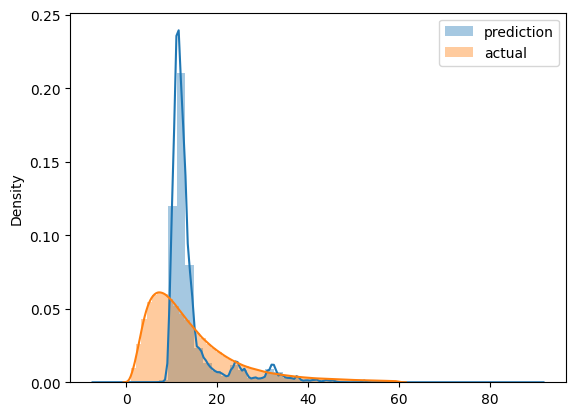

In [14]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [16]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [ ]:
df_train = read_dataframe('/workspaces/mlops/02-experiment_tracking/data/green_tripdata_2021-01.parquet')
df_val = read_dataframe('/workspaces/mlops/02-experiment_tracking/data/green_tripdata_2021-02.parquet')

In [19]:
len(df_train), len(df_val)

(73908, 61921)

In [21]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

mean_squared_error(y_val, y_pred)

60.197661679003765

In [ ]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

124.70805194645156

In [33]:
#créer un expérimentateur avec jeu de données différent:
with mlflow.start_run():
    alpha=0.1
    #créer un tag permettant de distinguer les expérimentations:
    mlflow.set_tag("developer","Anas")
    mlflow.log_param("train-data-path","/workspaces/mlops/02-experiment_tracking/data/green_tripdata_2021-01.parquet")
    mlflow.log_param("valid-data-path","/workspaces/mlops/02-experiment_tracking/data/green_tripdata_2021-02.parquet")
    
    lr = Lasso(alpha)
    #enregistrer le paramètre alpha
    mlflow.log_param("alpha",alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse=mean_squared_error(y_val, y_pred)
    #enregistrer l'erreur carrée moyenne
    mlflow.log_metric("rmse",rmse)

🏃 View run industrious-moth-427 at: http://localhost:5000/#/experiments/898637515699266746/runs/19c16238d37046d49031ee89f93e609f
🧪 View experiment at: http://localhost:5000/#/experiments/898637515699266746


In [38]:
import xgboost as xgb
from hyperopt import fmin,tpe,hp,STATUS_OK,Trials
from hyperopt.pyll import scope
import numpy as np

In [32]:
print(sklearn.__version__)


1.6.1


In [29]:
train=xgb.DMatrix(X_train, label= y_train)
valid=xgb.DMatrix(X_val,label=y_val)

In [ ]:
#permet de garder atomatiquement les logs des expérimentations
mlflow.sklearn.autolog()

In [ ]:
#définir la fonction objective
#permet de lancer une combinaison d'hyperparametres
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        # rmse = mean_squared_error(y_val, y_pred, squared=False)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))

        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [ ]:
#définir l'espace d'exploration
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}
#définir les parametres d'hyperplot
best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)